# Notebook 13: Enterprise Stress Testing & Scenario Analysis

## Project: Enterprise Credit Risk Modelling & Independent Model Validation (SR 11-7)

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

root_path = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = root_path / "src"
for p in [str(root_path), str(src_path)]:
    if p not in sys.path:
        sys.path.insert(0, p)

sns.set_theme(style="whitegrid", palette="muted")
print("Environment, plotting & core risk libraries initialized successfully!")

Environment, plotting & core risk libraries initialized successfully!


In [2]:
data_file = root_path / "data" / "processed" / "accepted_2007_to_2018Q4_feature_engineered.csv.gz"
if data_file.is_file():
    df = pd.read_csv(data_file, nrows=50000, low_memory=False)
    bad = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "Late (31-120 days)"]
    good = ["Fully Paid", "Does not meet the credit policy. Status:Fully Paid"]
    df["target"] = np.nan
    df.loc[df["loan_status"].isin(bad), "target"] = 1.0
    df.loc[df["loan_status"].isin(good), "target"] = 0.0
    df = df.dropna(subset=["target"]).copy()
    df["target"] = df["target"].astype(int)
    num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low", "revol_util"]
    for c in num_cols:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median())
else:
    df = mock_df.copy()

print(f"Dataset Loaded: {len(df):,} loans | Default Rate: {df['target'].mean():.4%}")

Dataset Loaded: 44,252 loans | Default Rate: 20.9572%


In [3]:
from stress_testing.stress_engine import run_portfolio_stress_test
from models.boosting_models import fit_lightgbm
num_feats = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "fico_range_low"]
lgb_res = fit_lightgbm(df[num_feats], df["target"])
predict_fn = lambda d: float(np.mean(lgb_res["model"].predict_proba(d[num_feats])[:, 1]))
stress_df = run_portfolio_stress_test(predict_fn, df, num_feats)
stress_df[["scenario_name", "mean_predicted_pd", "delta_pd_pct_points", "delta_expected_loss"]]

,scenario_name,mean_predicted_pd,delta_pd_pct_points,delta_expected_loss
0,Baseline (Current),20.96,0.00,0.00
1,Scenario 1: Income -10%,21.04,0.08,495163.18
2,Scenario 2: Income -20%,21.21,0.25,1519254.70
3,Scenario 3: DTI +15%,21.56,0.60,3604580.56
4,Scenario 4: Int Rate +2%,25.65,4.69,28320784.14
5,Scenario 5: Util +20%,20.96,0.00,0.00
6,Scenario 6: FICO -30 pts,22.41,1.45,8768160.13
7,Scenario 7: Loan Amount +15%,20.51,-0.45,15844879.97
8,Macro Adverse (Slowdown),22.34,1.38,8315589.72
9,Macro Severe Adverse (Crisis),31.08,10.12,61061416.87


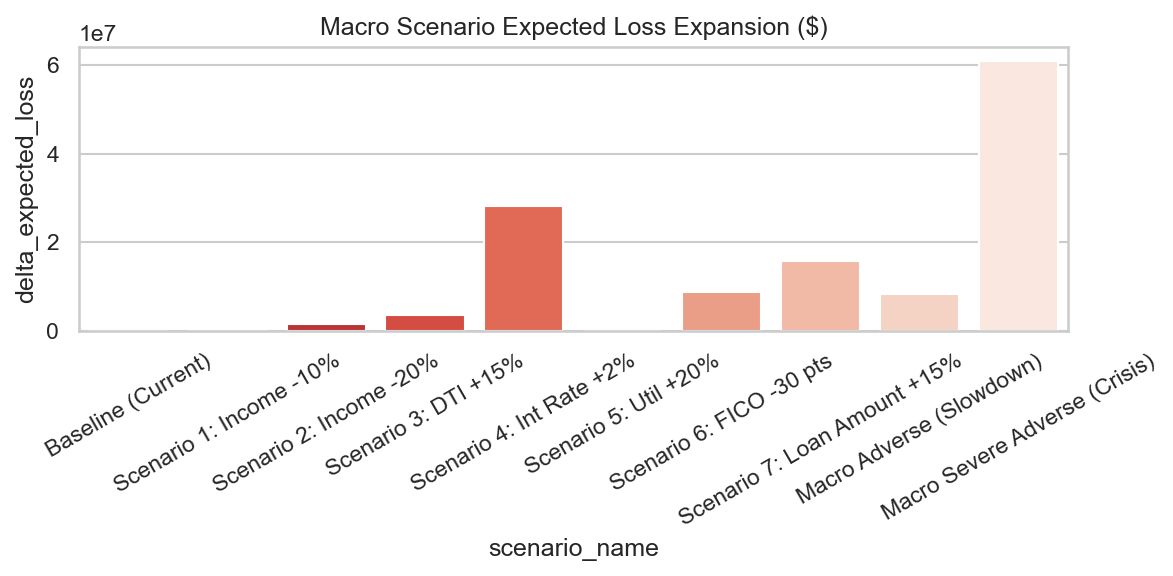

In [4]:
plt.figure(figsize=(8, 4))
sns.barplot(data=stress_df, x="scenario_name", y="delta_expected_loss", hue="scenario_name", palette="Reds_r", legend=False)
plt.xticks(rotation=30)
plt.title("Macro Scenario Expected Loss Expansion ($)")
plt.tight_layout()
plt.show()